# LM Lab: Neural models for word vector representation

- Alejandro Silva
- Fernando Baña
- Daniel Prieto

In [1]:
import os

os.makedirs("data", exist_ok=True)
os.makedirs("models", exist_ok=True)

# Disable TensorFlow logging
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import layers
from tqdm import tqdm
from utils import *
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

FILE_PATH = "data/eng_news_2024_30k_sentences.txt"

## Data Cleaning and Preprocessing

We are given the txt file in the following format:

- Each line contains a sentence.
- Each sentence is a sequence of words separated by spaces.
- All sentences end with a period ('.').


In [2]:
text_data = load_dataset(FILE_PATH)

print(f"Loaded {len(text_data)} sentences")
print(f"First 5 sentences:")
for i in range(5):
    print(f"{i+1}: {text_data[i]}")

Loaded 30000 sentences
First 5 sentences:
1: $10-$15 suggested donation goes to Falmouth Land Trust.
2: $20,000: Lower Adirondack Pride Festival, June 1 in City Park, Glens Falls.
3: $239.4 billion (32nd), comparable to Hungary.
4: $35, $75 family of three or more.
5: £1,200: Provision of funding for Year 1 & Year 2 children to attend Enchantica Christmas Show / Grove Road Community Primary School.


## Word Embedding Models

In this section we will implement the required models. The models are based on the **prediction of words given their context**. The models will have the following characteristics:

- They will take as input the context, n words preciding/following the target word.
- They will try to predict the target word given the context.

Therefore we have:
- Input $\rightarrow$ Context (n words)
- Output $\rightarrow$ Target word

### Tokenization and Vocabulary Building

To implement the word embedding models, we first need to preprocess the text data. This involves tokenizing the sentences and building a vocabulary of unique words. For this task we will use the TextVectorizer from the Keras library, and use it to convert the sentences into sequences of integersmm, where each integer represents a unique word in the vocabulary.

We will use a limited vocabulary size to keep the models to train.

In [3]:
VOCAB_SIZE = 20000

vectorizer = build_vectorizer(text_data, VOCAB_SIZE)

# Get the vocabulary and create mappings from words to indices
vocab, word_to_index, index_to_word = build_vocab_mappings(vectorizer)
print(f"Vocabulary size: {len(vocab)}")
print(f"First 10 words in the vocabulary: {vocab[:10]}")

I0000 00:00:1778788964.617763 7808345 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1778788964.617788 7808345 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Vocabulary size: 20000
First 10 words in the vocabulary: ['', '[UNK]', np.str_('the'), np.str_('to'), np.str_('and'), np.str_('of'), np.str_('a'), np.str_('in'), np.str_('for'), np.str_('on')]


### Generating Training Data for the Models

Now that we have the vectorizer adapted to out data, we can start generating the training data for the models.

In [4]:
experiments = {}

WINDOW_SIZES = [2, 4, 8]  # Number of words to the left and right of the target word

sequences = vectorizer(text_data).numpy()
for WINDOW_SIZE in WINDOW_SIZES:
    print(f"\n Context-target pairs with window size: {WINDOW_SIZE}")
    # First transform the sentences into sequences of integers

    X_train, y_train = build_context_target_pairs(sequences, WINDOW_SIZE)

    print(f"Number of training samples: {len(X_train)}")
    print(f"Sample training data (context -> target):")
    print(f"Context: {X_train[0]} -> Target: {y_train[0]}")
    print(
        f"Context: {[str(index_to_word[idx]) for idx in X_train[0]]} -> Target: {index_to_word[y_train[0]]}"
    )

    experiments[WINDOW_SIZE] = (X_train, y_train)


 Context-target pairs with window size: 2


100%|██████████| 30000/30000 [00:00<00:00, 69339.64it/s]


Number of training samples: 470316
Sample training data (context -> target):
Context: [8437 1636  822    3] -> Target: 5602
Context: ['1015', 'suggested', 'goes', 'to'] -> Target: donation

 Context-target pairs with window size: 4


100%|██████████| 30000/30000 [00:00<00:00, 127810.96it/s]


Number of training samples: 354734
Sample training data (context -> target):
Context: [4675  855    1 3153  422  423    7  148] -> Target: 940
Context: ['20000', 'lower', '[UNK]', 'pride', 'june', '1', 'in', 'city'] -> Target: festival

 Context-target pairs with window size: 8


100%|██████████| 30000/30000 [00:00<00:00, 120651.02it/s]


Number of training samples: 166319
Sample training data (context -> target):
Context: [14997  4470     5   699     8    75   423    75   229     3  1666     1
   999   182  6490   221] -> Target: 410
Context: ['£1200', 'provision', 'of', 'funding', 'for', 'year', '1', 'year', 'children', 'to', 'attend', '[UNK]', 'christmas', 'show', 'grove', 'road'] -> Target: 2


### Embedding Model Architecture

In [6]:
EMBEDDING_DIMS = [50, 100, 200]
EPOCHS = 20
BATCH_SIZE = 256

for WINDOW_SIZE in WINDOW_SIZES:
    X_train, y_train = experiments[WINDOW_SIZE]

    for EMBEDDING_DIM in EMBEDDING_DIMS:
        print(
            f"\nTraining CBOW model with window size {WINDOW_SIZE} and embedding dim {EMBEDDING_DIM}"
        )
        model = build_word_emb_model(VOCAB_SIZE, EMBEDDING_DIM, WINDOW_SIZE * 2)
        model.summary()

        save_path = (
            f"models/word_embed_w{WINDOW_SIZE}_emb{EMBEDDING_DIM}_v{VOCAB_SIZE}.keras"
        )

        callbacks = get_callbacks(save_path)

        history = model.fit(
            X_train,
            y_train,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            validation_split=0.1,
            callbacks=callbacks,
        )

        # Save the trained embeddings
        trained_embeddings = model.get_layer("word_embeddings").get_weights()[0]

        # Save as a numpy array so it can be used later
        np.save(
            f"embeddings/embeddings_w{WINDOW_SIZE}_emb{EMBEDDING_DIM}_v{VOCAB_SIZE}.npy",
            trained_embeddings,
        )

        experiments[(WINDOW_SIZE, EMBEDDING_DIM)] = {
            "model": model,
            "history": history,
            "embeddings": trained_embeddings,
        }


Training CBOW model with window size 2 and embedding dim 50


Model: "word_emb_d50_c4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ context_words (InputLayer)      │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ word_embeddings (Embedding)     │ (None, 4, 50)          │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 50)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ target_probs (Dense)            │ (None, 20000)          │     1,020,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,020,000 (7.71 MB)

 Trainable params: 2,020,000 (7.71 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ context_words (InputLayer)      │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ word_embeddings (Embedding)     │ (None, 16, 200)        │     4,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_9      │ (None, 200)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ target_probs (Dense)            │ (None, 20000)          │     4,020,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,020,000 (30.59 MB)

 Trainable params: 8,020,000 (30.59 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
585/585 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.0555 - loss: 8.1013
Epoch 1: val_loss improved from None to 7.11587, saving model to models/word_embed_w8_emb200_v20000.keras

Epoch 1: finished saving model to models/word_embed_w8_emb200_v20000.keras
585/585 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.0596 - loss: 7.4892 - val_accuracy: 0.0631 - val_loss: 7.1159
Epoch 2/20
584/585 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.0643 - loss: 6.9624
Epoch 2: val_loss improved from 7.11587 to 7.04312, saving model to models/word_embed_w8_emb200_v20000.keras

Epoch 2: finished saving model to models/word_embed_w8_emb200_v20000.keras
585/585 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.0652 - loss: 6.9645 - val_accuracy: 0.0631 - val_loss: 7.0431
Epoch 3/20
585/585 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.0687 - loss: 6.8702
Epoch 3: val_loss improved from 7.04312 to 7.00181, saving model to models/word_embed_w8_emb200_v20000.keras

Epoch 3: finished saving

## Analysis of the Results of Word Embeddings

In order to analyze the results from the different models we will use the following metrics:

- **Cosine Similarity**: To compare the similarity between the given target words and the results obtained from the models.
- **Visualization using t-SNE**: To visualize the word embeddings in a 2D space and observe how words are grouped together 

In [8]:
import pandas as pd
from IPython.display import display

tables = {}
with open("materials/target_words.txt", "r") as f:
    target_words = [w.strip() for w in f if w.strip() in word_to_index]

print("Top 10 similar words per target word:\n")
for word in target_words:
    print(f"Target word: {word}")

    table_data = {}

    for w_size, e_dim in [(w, e) for w in WINDOW_SIZES for e in EMBEDDING_DIMS]:
        if (w_size, e_dim) in experiments:
            col_name = f"W={w_size} | D={e_dim}"

            # Get the trained embeddings matrix for this specific model
            embeddings = experiments[(w_size, e_dim)]["embeddings"]

            # Get the top 10 similar words using your util function
            top_10 = get_top_k_similar_words(
                word, embeddings, word_to_index, vocab, k=10
            )

            # Format the output to show both the word and its cosine similarity score
            table_data[col_name] = [
                f"{sim_word} ({score:.2f})" for sim_word, score in top_10
            ]

    if table_data:
        df = pd.DataFrame(table_data)
        # Create a clean index list: "#1", "#2", ..., "#10"
        df.index = [f"#{i+1}" for i in range(len(df))]

        display(df)

        tables[word] = df

# Save all the tables as a txt file
with open("similar_words_tables.txt", "w") as f:
    for word, df in tables.items():
        f.write(f"Target word: {word}\n")
        f.write(df.to_string())
        f.write("\n\n")

Top 10 similar words per target word:

Target word: everyone


,W=2 | D=50,W=2 | D=100,W=2 | D=200,W=4 | D=50,W=4 | D=100,W=4 | D=200,W=8 | D=50,W=8 | D=100,W=8 | D=200
#1,everybody (0.89),everybody (0.83),everybody (0.81),anybody (0.91),anybody (0.88),everybody (0.84),feel (0.96),work (0.93),work (0.89)
#2,me (0.87),me (0.82),me (0.79),everything (0.91),anything (0.86),anything (0.84),changes (0.96),people (0.92),weve (0.89)
#3,someone (0.86),someone (0.80),something (0.77),anything (0.90),everything (0.86),anybody (0.84),work (0.96),changes (0.92),changes (0.88)
#4,anything (0.84),something (0.80),anyone (0.77),everybody (0.89),everybody (0.85),everything (0.83),difficult (0.96),feel (0.92),difficult (0.88)
#5,anyone (0.83),anything (0.79),god (0.77),depressed (0.88),sad (0.84),sad (0.79),need (0.96),hard (0.91),hard (0.87)
#6,beijing (0.83),anyone (0.79),someone (0.76),merchan (0.87),unhappy (0.82),anyone (0.79),hard (0.96),difficult (0.91),feel (0.87)
#7,something (0.83),everything (0.79),somebody (0.75),sad (0.86),vulnerabilities (0.82),resonate (0.79),denying (0.95),weve (0.91),things (0.87)
#8,god (0.83),god (0.78),everything (0.75),vulnerabilities (0.86),okay (0.81),come (0.79),people (0.95),need (0.90),go (0.87)
#9,everything (0.82),somebody (0.77),anything (0.74),evo (0.85),purse (0.81),okay (0.78),want (0.95),positive (0.90),that’s (0.87)
#10,nothing (0.80),nothing (0.74),beijing (0.73),polish (0.85),easy (0.80),grateful (0.78),motivated (0.95),nothing (0.90),positive (0.86)


Target word: music


,W=2 | D=50,W=2 | D=100,W=2 | D=200,W=4 | D=50,W=4 | D=100,W=4 | D=200,W=8 | D=50,W=8 | D=100,W=8 | D=200
#1,tunnels (0.80),arts (0.70),color (0.61),tata (0.81),hair (0.79),hair (0.73),longtime (0.97),longtime (0.94),books (0.90)
#2,enrichment (0.79),color (0.70),padukone (0.61),paint (0.80),forms (0.79),forms (0.72),lands (0.97),books (0.94),kimetsu (0.90)
#3,margarine (0.78),art (0.69),art (0.61),forms (0.80),paint (0.77),bedding (0.72),frank (0.97),acting (0.94),longtime (0.89)
#4,lynn (0.78),diversity (0.66),tunnels (0.61),vitamins (0.79),soulful (0.77),paint (0.72),adds (0.96),sick (0.93),hair (0.89)
#5,diversity (0.77),tunnels (0.66),folders (0.60),hair (0.79),dragon (0.76),clutches (0.71),pieces (0.96),pieces (0.93),acting (0.89)
#6,aspiration (0.77),reggae (0.66),dressing (0.60),privileged (0.79),glass (0.75),privileged (0.71),acting (0.96),hair (0.93),slammed (0.89)
#7,masala (0.77),agriculture (0.66),kerr (0.60),potassium (0.79),eyes (0.75),adored (0.70),everywhere (0.96),kimetsu (0.93),pieces (0.89)
#8,fats (0.76),burdens (0.65),arts (0.60),rattled (0.78),potassium (0.74),potassium (0.70),“every (0.96),head (0.93),sick (0.89)
#9,folders (0.76),furness (0.65),furness (0.60),soulful (0.78),“beach (0.74),grandchildren (0.70),nova (0.96),wellknown (0.93),entrepreneurs (0.89)
#10,roman (0.76),organiser (0.65),frothy (0.59),ensemble (0.78),aspirations (0.74),grossly (0.70),shah (0.96),lands (0.92),what’s (0.88)


Target word: running


...

,W=2 | D=50,W=2 | D=100,W=2 | D=200,W=4 | D=50,W=4 | D=100,W=4 | D=200,W=8 | D=50,W=8 | D=100,W=8 | D=200
#1,years (0.91),years (0.89),years (0.88),months (0.87),years (0.87),months (0.86),conceded (0.94),launches (0.90),decades (0.85)
#2,months (0.90),months (0.89),days (0.87),years (0.85),months (0.86),years (0.86),parole (0.94),decades (0.88),advance (0.82)
#3,days (0.89),days (0.88),months (0.86),days (0.84),days (0.84),days (0.83),communion (0.93),remembrance (0.88),morecambe (0.82)
#4,decades (0.87),decades (0.84),decades (0.83),seven (0.82),seven (0.81),hours (0.81),hiding (0.93),advance (0.88),launches (0.82)
#5,minutes (0.85),minutes (0.83),minutes (0.82),seasons (0.81),hours (0.81),minutes (0.80),donors (0.93),seek (0.88),caroline (0.82)
#6,hours (0.83),hours (0.81),hours (0.79),minutes (0.81),four (0.80),seven (0.79),republicans (0.93),judges (0.87),judges (0.82)
#7,games (0.80),seasons (0.75),games (0.74),hours (0.81),seasons (0.79),five (0.79),here” (0.93),resistance (0.87),remain (0.82)
#8,times (0.77),games (0.75),seasons (0.72),arrived (0.80),films (0.78),four (0.78),iss (0.93),crop (0.87),jail (0.82)
#9,seasons (0.75),times (0.72),turnovers (0.69),four (0.80),minutes (0.78),seasons (0.77),specter (0.92),gardaí (0.87),remembrance (0.81)
#10,eight (0.74),turnovers (0.71),decade (0.68),strides (0.79),games (0.77),games (0.76),resistance (0.92),decided (0.87),90 (0.81)


Target word: military


,W=2 | D=50,W=2 | D=100,W=2 | D=200,W=4 | D=50,W=4 | D=100,W=4 | D=200,W=8 | D=50,W=8 | D=100,W=8 | D=200
#1,government (0.73),government (0.70),defense (0.63),state (0.79),foreign (0.72),foreign (0.68),production (0.96),conflict (0.94),shanghai (0.89)
#2,party (0.72),defense (0.66),cbi (0.63),council (0.78),state (0.71),thereby (0.65),arkansas (0.96),ny (0.94),ministry (0.88)
#3,highway (0.71),council (0.64),council (0.61),foreign (0.77),meddling (0.68),climate (0.64),biodiversity (0.96),shanghai (0.93),conflict (0.88)
#4,defense (0.69),crew (0.63),government (0.61),public (0.72),force (0.68),state (0.63),1993 (0.96),undermine (0.93),belonging (0.88)
#5,council (0.68),army (0.62),army (0.61),district (0.70),council (0.68),efforts (0.63),ny (0.96),characterised (0.93),undermine (0.88)
#6,crew (0.67),ministers (0.62),resolution (0.61),threaten (0.69),government (0.67),reacted (0.63),conflict (0.96),addition (0.93),paltry (0.88)
#7,society (0.67),congress (0.61),boundary (0.60),reacted (0.69),federal (0.66),federal (0.62),ministry (0.96),ministry (0.93),transportation (0.88)
#8,dollar (0.67),highway (0.61),narrative (0.60),government (0.69),shakeup (0.66),meddling (0.62),addition (0.96),jewish (0.93),ambition (0.88)
#9,stressing (0.67),entity (0.61),chang (0.60),federal (0.69),intelligence (0.65),shakeup (0.62),jewish (0.96),destruction (0.93),destruction (0.88)
#10,ratification (0.66),party (0.61),society (0.59),meddling (0.68),climate (0.64),government (0.61),missiles (0.96),discontent (0.92),saddened (0.87)


Target word: always


,W=2 | D=50,W=2 | D=100,W=2 | D=200,W=4 | D=50,W=4 | D=100,W=4 | D=200,W=8 | D=50,W=8 | D=100,W=8 | D=200
#1,really (0.89),actually (0.84),really (0.82),else (0.95),else (0.90),else (0.87),like (0.96),know (0.93),know (0.91)
#2,actually (0.87),really (0.83),actually (0.81),too (0.92),too (0.89),quite (0.86),might (0.96),actually (0.93),actually (0.90)
#3,absolutely (0.87),definitely (0.81),definitely (0.79),quite (0.92),quite (0.88),too (0.85),thinking (0.96),pretty (0.92),don’t (0.90)
#4,quite (0.86),absolutely (0.80),absolutely (0.78),really (0.92),really (0.87),really (0.84),actually (0.96),doing (0.92),doing (0.90)
#5,definitely (0.85),“it (0.79),possibly (0.77),definitely (0.90),definitely (0.85),definitely (0.83),you’re (0.96),really (0.92),really (0.89)
#6,“it (0.84),possibly (0.78),“it (0.77),why (0.89),words (0.83),why (0.82),really (0.96),don’t (0.92),so (0.89)
#7,fortunately (0.84),quite (0.78),“he (0.76),“i (0.87),why (0.83),words (0.81),pretty (0.95),thinking (0.92),thinking (0.89)
#8,possibly (0.83),fortunately (0.77),quite (0.75),wrong (0.86),actually (0.81),wrong (0.79),very (0.95),good (0.92),because (0.87)
#9,never (0.82),never (0.77),“she (0.74),something (0.86),“i (0.81),someone (0.79),know (0.95),sure (0.91),sure (0.87)
#10,simply (0.81),“he (0.76),nothing (0.71),never (0.86),something (0.81),actually (0.79),doing (0.95),so (0.91),good (0.87)


### t-SNE Visualizations

In order to visualize the word embeddings, we can use t-SNE to reduce the dimensionality of the embeddings to 2D and plot them. This allows us to see how the words are grouped together in the embedding space and identify clusters of similar words. 

To start we will create a plot with random embeddings, to see the difference between the random embeddings and the ones obtained after training the embedding layers. For this we will just make one plot since the embeddings are random and should not have any structure. After that we will create different plots for different models to see the differences between them.

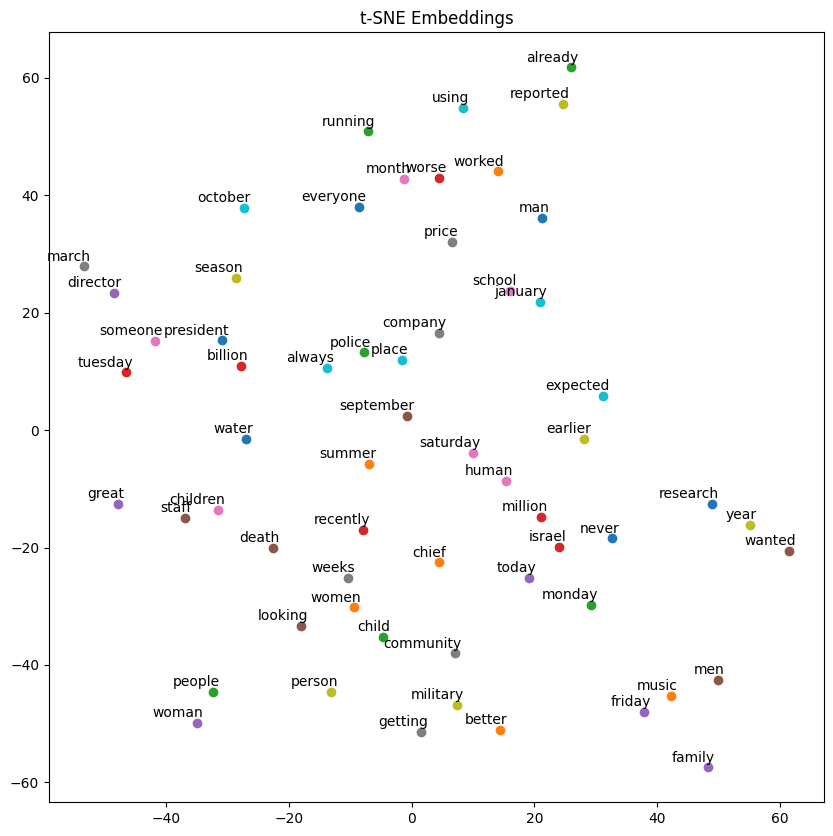

In [13]:
# Visualization BEFORE training -> random embeddings
untrained_embeddings = np.random.randn(*trained_embeddings.shape)
visualize_tsne_embeddings(target_words, untrained_embeddings, word_to_index)

As we can see in the plot, the random embeddings do not have any kind of structure and the words are scattered randomly. Words do not have any similarity with the ones close to them. 

TODO: after running it one last time, we can comment here more explicitely with examples from the plots.


 t-SNE visualization for window size 2 and embedding dim 50


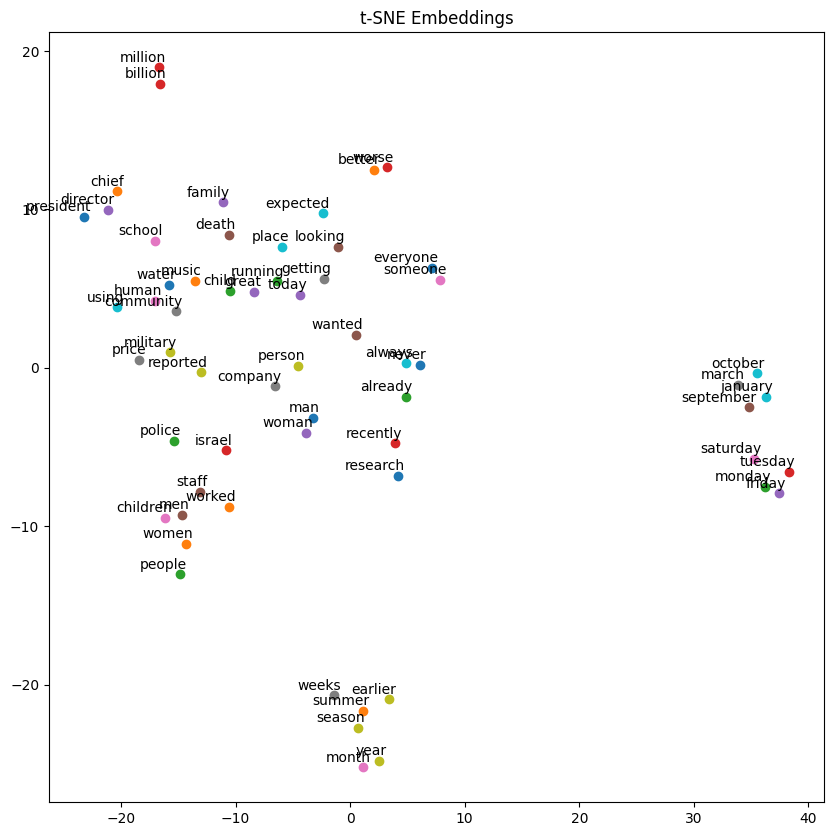


 t-SNE visualization for window size 2 and embedding dim 100


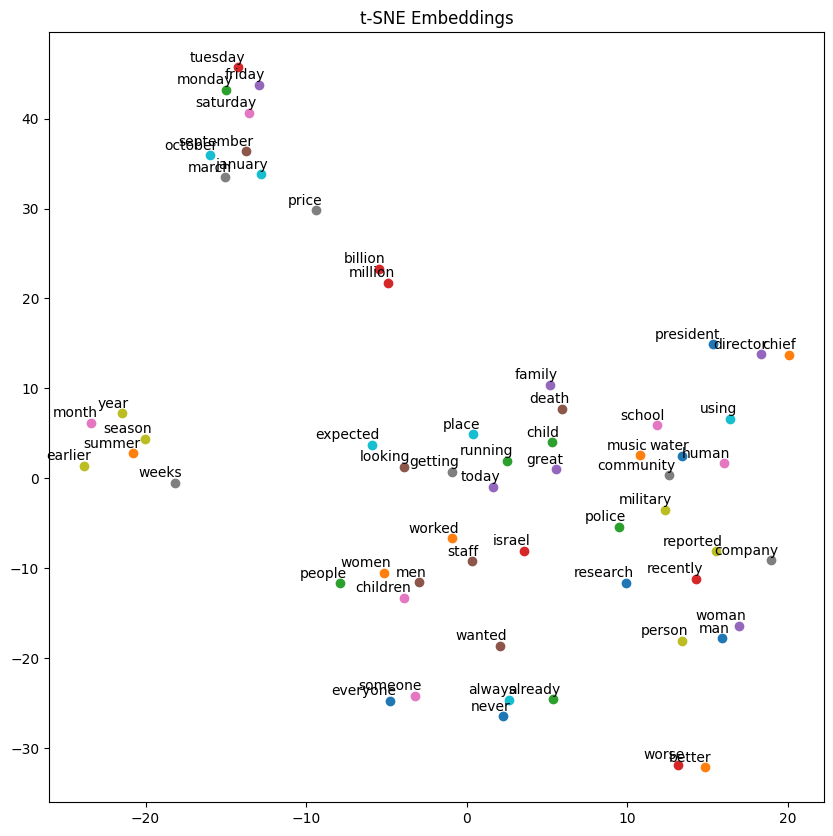


 t-SNE visualization for window size 2 and embedding dim 200


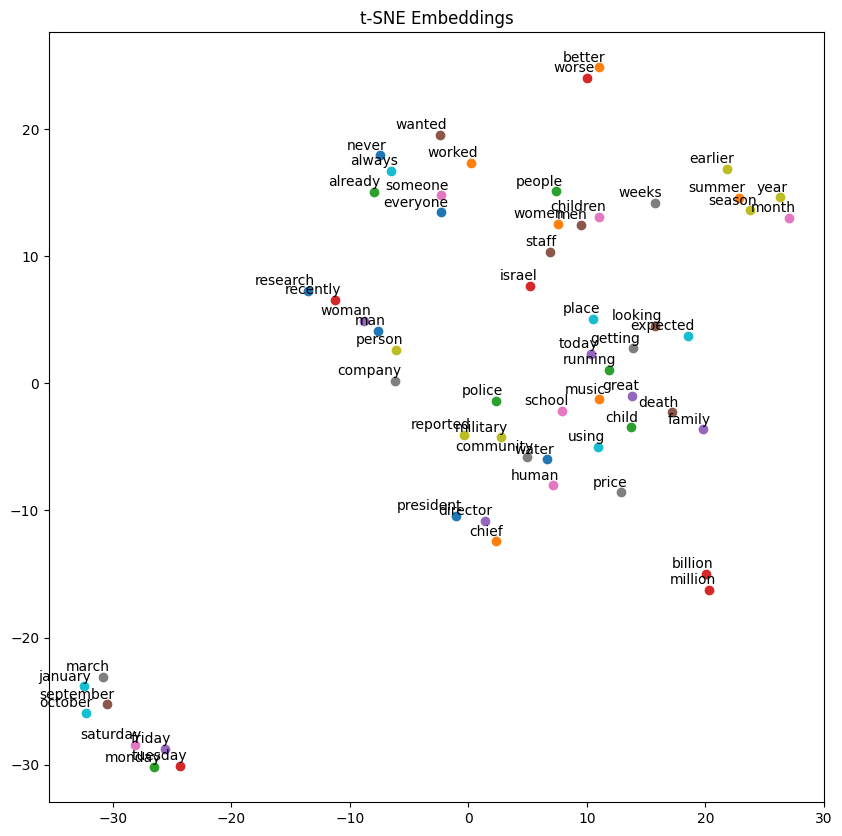


 t-SNE visualization for window size 4 and embedding dim 50


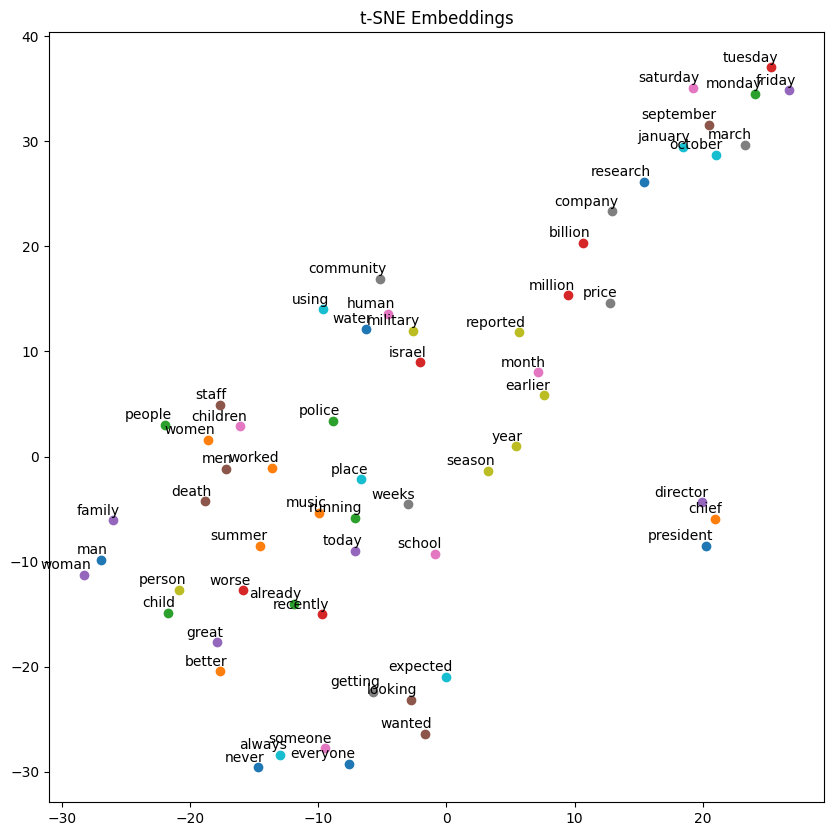


 t-SNE visualization for window size 4 and embedding dim 100


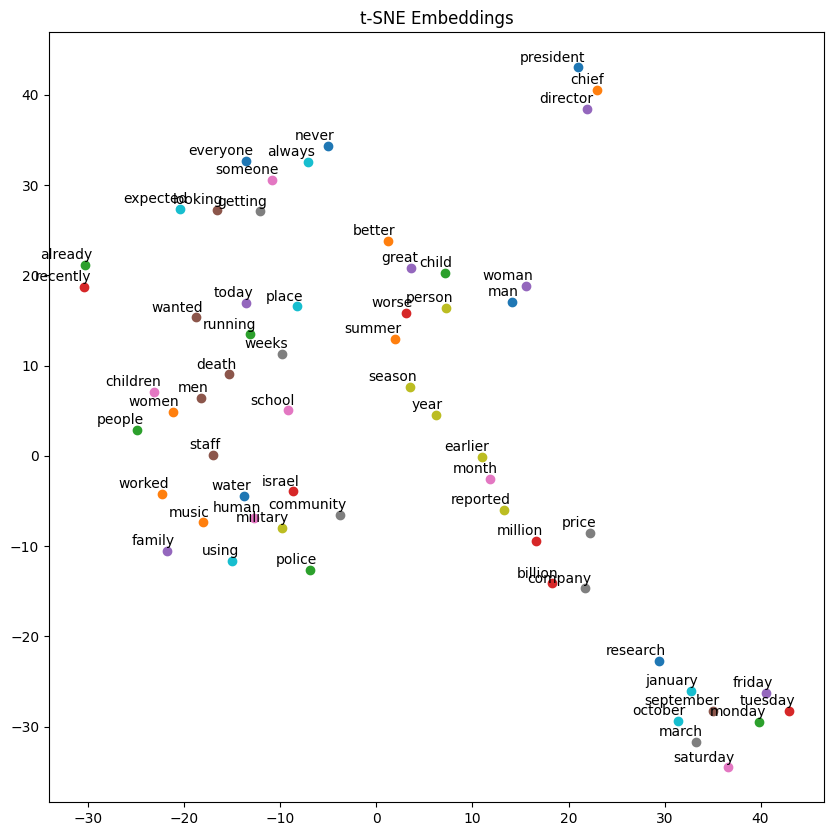


 t-SNE visualization for window size 4 and embedding dim 200


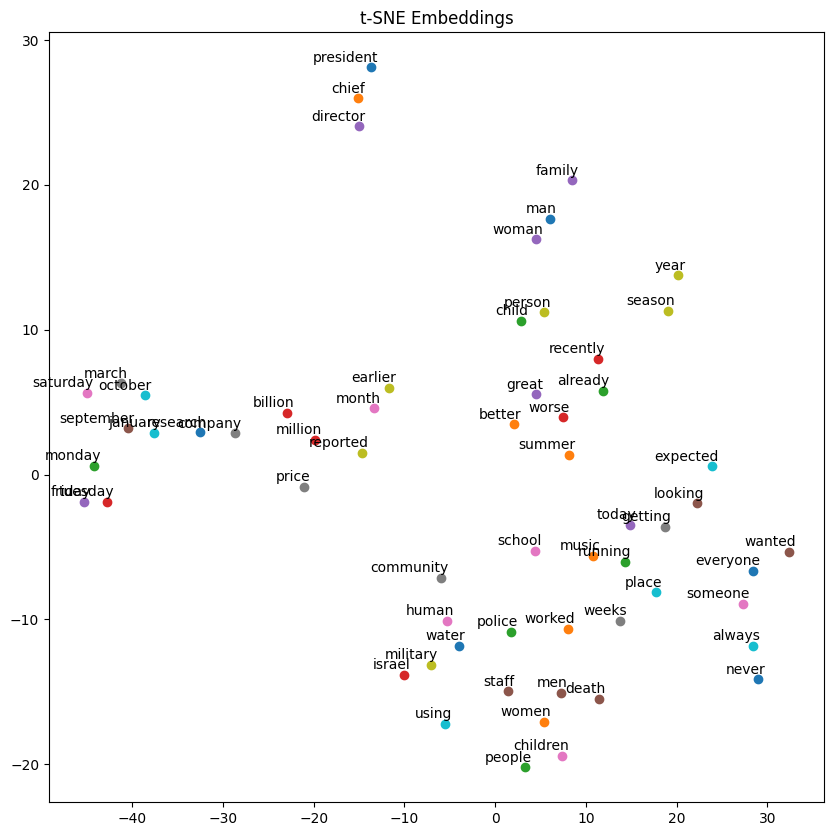


 t-SNE visualization for window size 8 and embedding dim 50


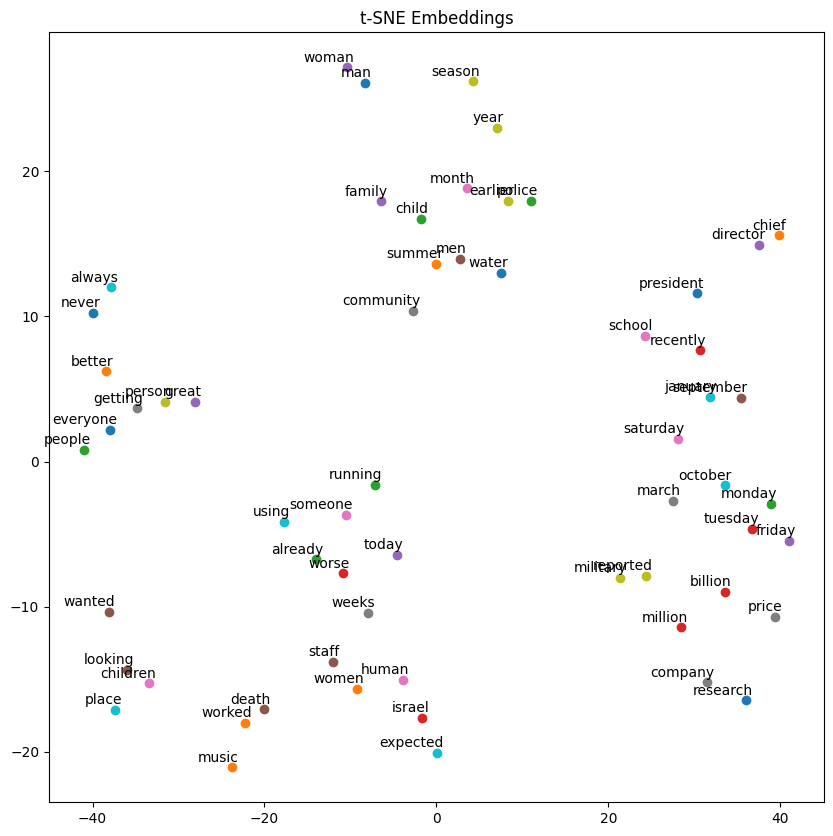


 t-SNE visualization for window size 8 and embedding dim 100


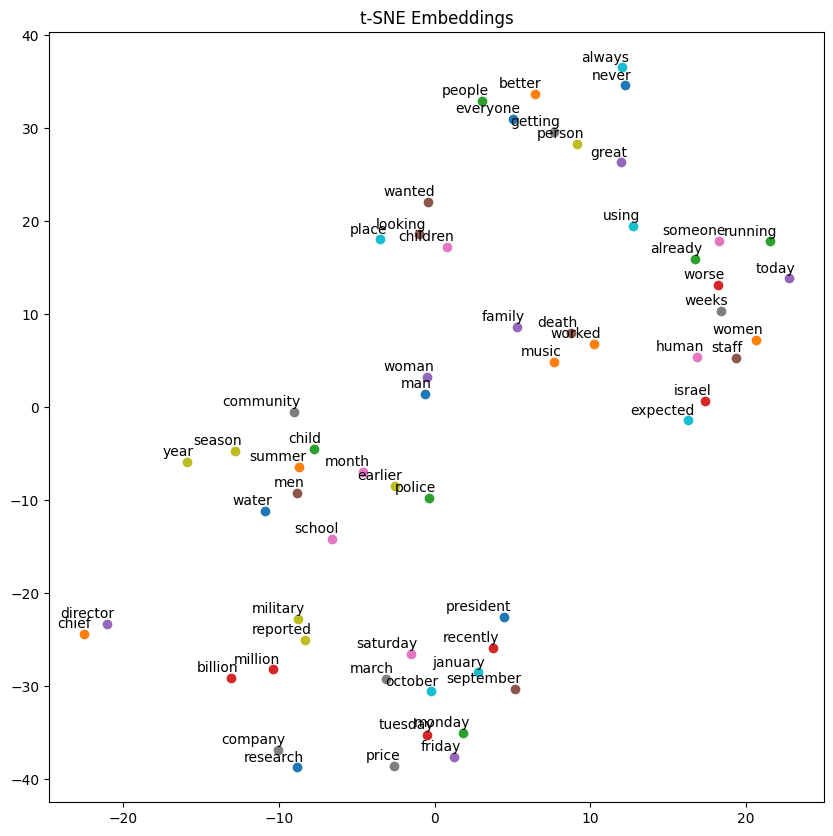


 t-SNE visualization for window size 8 and embedding dim 200


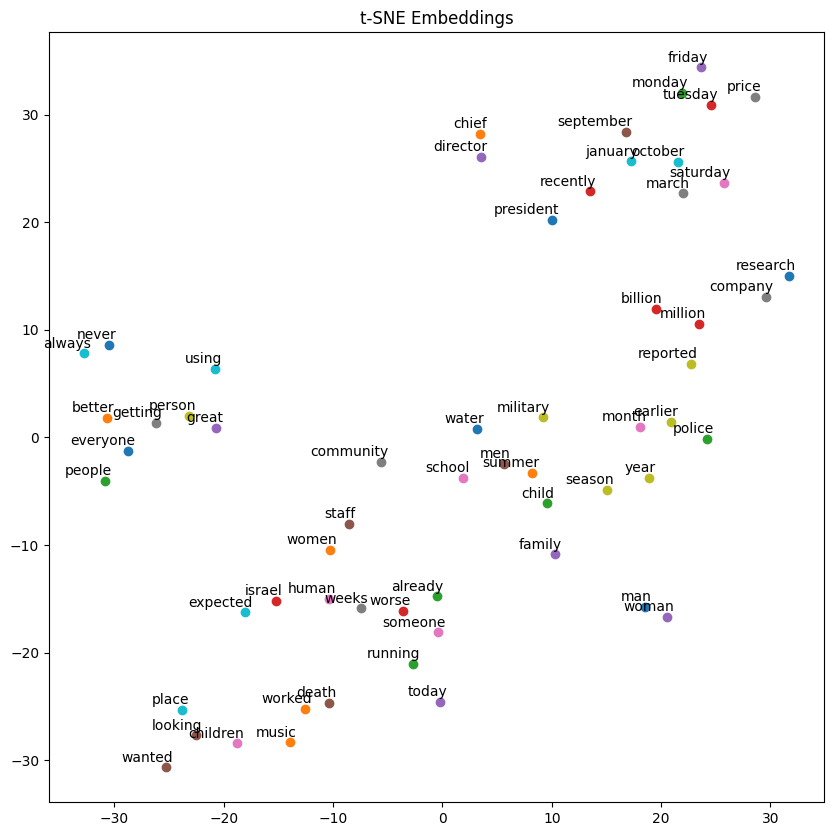

In [14]:
for w_size, e_dim in [(w, e) for w in WINDOW_SIZES for e in EMBEDDING_DIMS]:
    if (w_size, e_dim) in experiments:
        print(
            f"\n t-SNE visualization for window size {w_size} and embedding dim {e_dim}"
        )
        embeddings = experiments[(w_size, e_dim)]["embeddings"]
        visualize_tsne_embeddings(target_words, embeddings, word_to_index)

In [ ]:
from keras.datasets import reuters

MAX_LEN = 256

def build_classifier(
    embeddings_matrix=None,
    trainable=False,
    num_classes=46,
    max_len=256,
    vocab_size=20000,
) -> keras.Model:
    """
    Builds the classifier. If embeddings_matrix is provided, it uses our pre-trained embeddings.
    """
    input_dim = vocab_size if embeddings_matrix is None else embeddings_matrix.shape[0]
    output_dim = 100 if embeddings_matrix is None else embeddings_matrix.shape[1]

    inputs = layers.Input(shape=(max_len,), dtype="int32", name="input_tokens")
    embeds = None
    if embeddings_matrix is not None:
        print("Using PRE-TRAINED embeddings.")
        embeds = layers.Embedding(
            input_dim=embeddings_matrix.shape[0],
            output_dim=embeddings_matrix.shape[1],
            weights=[embeddings_matrix],
            trainable=trainable,  # Experiment with True vs False
            input_length=MAX_LEN,
        )(inputs)
    else:
        print("Using RANDOM (scratch) embeddings.")
        embeds = layers.Embedding(input_dim=input_dim, output_dim=output_dim)(inputs)

    # Standard 1D classification head
    x = layers.Conv1D(128, 5, activation="relu")(embeds)
    x = layers.MaxPooling1D(5)(x)
    x = layers.Conv1D(128, 5, activation="relu")(x)
    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    name = (
        "classifier_random_emb"
        if embeddings_matrix is None
        else "classifier_pretrained_emb"
    )
    model = keras.Model(inputs, outputs, name=f"{name}_v{vocab_size}")

    model.compile(
        optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
    )
    return model


def get_classifier_callbacks(model_path: str, patience: int = 5):
    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True
    )
    path = keras.callbacks.ModelCheckpoint(
        filepath=model_path,
        monitor="val_loss",
        save_best_only=True,
    )

    return [early_stopping, path]

In [33]:
# Load the Reuters dataset from Keras
NUM_WORDS = len(vocab)  # Should ideally match the vocabulary size created in Phase 1
NUM_CLASSES = 46
MAX_LEN = 256

(x_train_reuters, y_train), (x_test_reuters, y_test) = reuters.load_data(
    num_words=NUM_WORDS, test_split=0.1, seed=SEED
)

# Pad sequences so they all have the same length
x_train = tf.keras.preprocessing.sequence.pad_sequences(x_train_reuters, maxlen=MAX_LEN)
x_test = tf.keras.preprocessing.sequence.pad_sequences(x_test_reuters, maxlen=MAX_LEN)

# Convert labels to categorical
y_train = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test = tf.keras.utils.to_categorical(y_test, NUM_CLASSES)

word_index_reuters = reuters.get_word_index()
INDEX_FROM = 3  # word indices are offset by 3

In [34]:
def adapt_embeddings_to_reuters(
    pretrained_embeddings,
    word_to_index,
    word_index_reuters,
    embed_dim,
    num_words=20000,
    index_from=3,
):
    embedding_matrix = np.random.uniform(-0.1, 0.1, size=(num_words, embed_dim))

    hits = 0
    misses = 0

    for word, i in word_index_reuters.items():
        actual_i = i + index_from
        if actual_i >= num_words:  # index out of range for our vocab size
            continue

        if word in word_to_index:
            embedding_matrix[actual_i] = pretrained_embeddings[word_to_index[word]]
            hits += 1
        else:
            misses += 1

        embedding_matrix[0] = np.zeros(pretrained_embeddings.shape[1])  # Padding token

    print(f"\nAdapted embeddings to Reuters vocab")
    print(f"HITS = {hits}, MISSES = {misses}\n")

In [35]:
baseline_model = build_classifier(embeddings_matrix=None)
callbacks = get_classifier_callbacks("models/classifier_rand_baseline.keras", 5)
baseline_history = baseline_model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks,
)
baseline_loss, baseline_acc = baseline_model.evaluate(x_test, y_test, verbose=0)

print(f"Baseline Accuracy: {baseline_acc:.4f}")

Using RANDOM (scratch) embeddings.
Epoch 1/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.4942 - loss: 1.9577 - val_accuracy: 0.5826 - val_loss: 1.6142
Epoch 2/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.6027 - loss: 1.5073 - val_accuracy: 0.6380 - val_loss: 1.4665
Epoch 3/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.6935 - loss: 1.2156 - val_accuracy: 0.7043 - val_loss: 1.3165
Epoch 4/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.7664 - loss: 0.9458 - val_accuracy: 0.7191 - val_loss: 1.4072
Epoch 5/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.8080 - loss: 0.7818 - val_accuracy: 0.7438 - val_loss: 1.3749
Epoch 6/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.8308 - loss: 0.6654 - val_accuracy: 0.7359 - val_loss: 1.4755
Epoch 7/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.8522 - loss: 0.5960 - val_accuracy: 0.7567 - val_loss: 1.5872
Epoch 8/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accurac

In [36]:
# Now we can train the classifier using the pre-trained embeddings from our word embedding models.
for w_size, e_dim in [(w, e) for w in WINDOW_SIZES for e in EMBEDDING_DIMS]:
    if (w_size, e_dim) in experiments:
        print(
            f"\nClassifier with pre-trained embeddings of CONTEXT={w_size * 2} and EMBED_DIMS={e_dim}"
        )
        pretrained_embeddings = experiments[(w_size, e_dim)]["embeddings"]
        adapted_embeddings = adapt_embeddings_to_reuters(
            pretrained_embeddings,
            word_to_index,
            word_index_reuters,
            embed_dim=e_dim,
            num_words=VOCAB_SIZE,
            index_from=INDEX_FROM,
        )

        classifier_model = build_classifier(
            embeddings_matrix=pretrained_embeddings,
            trainable=False,
            num_classes=NUM_CLASSES,
            max_len=MAX_LEN,
            vocab_size=VOCAB_SIZE,
        )
        callbacks = get_classifier_callbacks(
            f"models/classifier_pretrained_emb_w{w_size}_e{e_dim}.keras", 5
        )

        history = classifier_model.fit(
            x_train,
            y_train,
            epochs=50,
            batch_size=32,
            validation_split=0.1,
            callbacks=callbacks,
            verbose=2,
        )

        loss, acc = classifier_model.evaluate(x_test, y_test, verbose=0)
        print(f"Pre-trained embeddings classifier: {acc:.4f}")


Classifier with pre-trained embeddings of CONTEXT=4 and EMBED_DIMS=50

Adapted embeddings to Reuters vocab
HITS = 9385, MISSES = 10611

Using PRE-TRAINED embeddings.
Epoch 1/50


/Users/daniprieto/miniconda3/envs/dl/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


285/285 - 6s - 22ms/step - accuracy: 0.4574 - loss: 2.2414 - val_accuracy: 0.5559 - val_loss: 1.7699
Epoch 2/50
285/285 - 5s - 17ms/step - accuracy: 0.5549 - loss: 1.8314 - val_accuracy: 0.5678 - val_loss: 1.7207
Epoch 3/50
285/285 - 5s - 17ms/step - accuracy: 0.5887 - loss: 1.6865 - val_accuracy: 0.5974 - val_loss: 1.6280
Epoch 4/50
285/285 - 4s - 16ms/step - accuracy: 0.6184 - loss: 1.5593 - val_accuracy: 0.6014 - val_loss: 1.6182
Epoch 5/50
285/285 - 5s - 16ms/step - accuracy: 0.6463 - loss: 1.4256 - val_accuracy: 0.6192 - val_loss: 1.6026
Epoch 6/50
285/285 - 5s - 16ms/step - accuracy: 0.6742 - loss: 1.3185 - val_accuracy: 0.6222 - val_loss: 1.6252
Epoch 7/50
285/285 - 5s - 16ms/step - accuracy: 0.6985 - loss: 1.1903 - val_accuracy: 0.6499 - val_loss: 1.4918
Epoch 8/50
285/285 - 4s - 16ms/step - accuracy: 0.7214 - loss: 1.0938 - val_accuracy: 0.6370 - val_loss: 1.5206
Epoch 9/50
285/285 - 5s - 17ms/step - accuracy: 0.7431 - loss: 1.0159 - val_accuracy: 0.6301 - val_loss: 1.6268
Epo

In [ ]:
# Now we can train the classifier using the pre-trained embeddings from our word embedding models.
for w_size, e_dim in [(w, e) for w in WINDOW_SIZES for e in EMBEDDING_DIMS]:
    if (w_size, e_dim) in experiments:
        print(
            f"\nClassifier with pre-trained embeddings of CONTEXT={w_size * 2} and EMBED_DIMS={e_dim}"
        )
        pretrained_embeddings = experiments[(w_size, e_dim)]["embeddings"]
        adapted_embeddings = adapt_embeddings_to_reuters(
            pretrained_embeddings,
            word_to_index,
            word_index_reuters,
            embed_dim=e_dim,
            num_words=VOCAB_SIZE,
            index_from=INDEX_FROM,
        )

        classifier_model = build_classifier(
            embeddings_matrix=pretrained_embeddings,
            trainable=True,
            num_classes=NUM_CLASSES,
            max_len=MAX_LEN,
            vocab_size=VOCAB_SIZE,
        )
        callbacks = get_classifier_callbacks(
            f"models/classifier_fine_tunned_emb_w{w_size}_e{e_dim}.keras", 5
        )

        history = classifier_model.fit(
            x_train,
            y_train,
            epochs=50,
            batch_size=32,
            validation_split=0.1,
            callbacks=callbacks,
            verbose=2,
        )

        loss, acc = classifier_model.evaluate(x_test, y_test, verbose=0)
        print(f"Pre-trained embeddings classifier: {acc:.4f}")


Classifier with pre-trained embeddings of CONTEXT=4 and EMBED_DIMS=50

Adapted embeddings to Reuters vocab
HITS = 9385, MISSES = 10611

Using PRE-TRAINED embeddings.
Epoch 1/50


/Users/daniprieto/miniconda3/envs/dl/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


285/285 - 9s - 33ms/step - accuracy: 0.4592 - loss: 2.2934 - val_accuracy: 0.5509 - val_loss: 1.7695
Epoch 2/50
285/285 - 6s - 20ms/step - accuracy: 0.5584 - loss: 1.8347 - val_accuracy: 0.5935 - val_loss: 1.6223
Epoch 3/50
285/285 - 6s - 20ms/step - accuracy: 0.6083 - loss: 1.6056 - val_accuracy: 0.6390 - val_loss: 1.5248
Epoch 4/50
285/285 - 6s - 20ms/step - accuracy: 0.6616 - loss: 1.4282 - val_accuracy: 0.6588 - val_loss: 1.4758
Epoch 5/50
285/285 - 5s - 19ms/step - accuracy: 0.7109 - loss: 1.2186 - val_accuracy: 0.6884 - val_loss: 1.3973
Epoch 6/50
285/285 - 5s - 19ms/step - accuracy: 0.7424 - loss: 1.0605 - val_accuracy: 0.7072 - val_loss: 1.3722
Epoch 7/50
285/285 - 5s - 19ms/step - accuracy: 0.7744 - loss: 0.9128 - val_accuracy: 0.7141 - val_loss: 1.3887
Epoch 8/50
285/285 - 6s - 20ms/step - accuracy: 0.7962 - loss: 0.8061 - val_accuracy: 0.6973 - val_loss: 1.4883
Epoch 9/50
285/285 - 6s - 19ms/step - accuracy: 0.8182 - loss: 0.7104 - val_accuracy: 0.6845 - val_loss: 1.6389
Epo